# Comparative Analysis: Bio_ClinicalBERT vs. MedGemma-4B

## Description
This notebook conducts a comparative analysis between traditional Encoder-based architectures (BERT) and modern Decoder-based Large Language Models (Gemma) on two specialized medical tasks:
1. **Medical Named Entity Recognition (NER)** using the `MedMentions` dataset.
2. **Medical Multiple-Choice QA** using the `MedQA` dataset.

### The Models
We will evaluate the following models previously published to the Hugging Face Hub:
* **NER (Classification):** `alexd063/bio-clinicalbert-finetuned-medmentions-v1`
* **NER (Generative):** `alexd063/gemma4bit-finetuned-medmentions`
* **QA (Classification):** `alexd063/bio-clinicalbert-finetuned-medqa`
* **QA (Generative):** `alexd063/gemma4bit-finetuned-medqa`

### Architecture Paradigms
* **BERT** treats NER as *Token Classification* and QA as *Sequence Classification* (outputting logits for 4 options).
* **Gemma** treats everything as *Text-to-Text Generation*, requiring strict prompt formatting and parsing of the output string.

In [1]:
%%capture
!pip install --upgrade transformers bitsandbytes accelerate trl torch unsloth datasets torchao seqeval

In [2]:
import unsloth
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from unsloth import FastLanguageModel
from seqeval.metrics import classification_report
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    BitsAndBytesConfig,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 4-bit Quantization Config for Gemma
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print(f"Using device: {DEVICE}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


---
## Part 1: Medical Named Entity Recognition (MedMentions)
We will run a qualitative side-by-side comparison. For BERT, we use the standard Hugging Face `TokenClassification` pipeline. For Gemma, we construct a prompt and parse the generative output.

In [3]:
print("Loading MedMentions Dataset...")
ner_dataset = load_dataset("Ben10x/MedMentions-MTI881-NER", split="test")

print("Loading BERT NER...")
bert_ner_id = "alexd063/bio-clinicalbert-finetuned-medmentions-v1"
bert_ner_tokenizer = AutoTokenizer.from_pretrained(bert_ner_id)
bert_ner_model = AutoModelForTokenClassification.from_pretrained(bert_ner_id).to(DEVICE)
bert_ner_model.eval()

id2label_ner = {int(k): v for k, v in bert_ner_model.config.id2label.items()}
label2id_ner = {v: k for k, v in id2label_ner.items()}

print("Loading Gemma NER...") # saved with unsloth — must be loaded with unsloth
gemma_ner_id = "alexd063/gemma4bit-finetuned-medmentions"
gemma_ner_model, gemma_ner_tokenizer = FastLanguageModel.from_pretrained(
    model_name=gemma_ner_id,
    max_seq_length=2048,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(gemma_ner_model)

Loading MedMentions Dataset...
Loading BERT NER...
Loading Gemma NER...
==((====))==  Unsloth 2025.11.1: Fast Gemma3 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma3ForConditionalGeneration(
      (model): Gemma3Model(
        (vision_tower): SiglipVisionModel(
          (vision_model): SiglipVisionTransformer(
            (embeddings): SiglipVisionEmbeddings(
              (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
              (position_embedding): Embedding(4096, 1152)
            )
            (encoder): SiglipEncoder(
              (layers): ModuleList(
                (0-15): 16 x SiglipEncoderLayer(
                  (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                  (self_attn): SiglipAttention(
                    (k_proj): lora.Linear(
                      (base_layer): Linear(in_features=1152, out_features=1152, bias=True)
                      (lora_dropout): ModuleDict(
                        (default): Identity()
                      )
                      (lora_A): ModuleDict(
  

In [ ]:
print("Running BERT NER on Test Set...")

def tokenize_and_align(examples):
    tokenized_examples = bert_ner_tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512,
    )
    labels = []

    # align labels to the subtokenized words
    # only labels the first subtoken of a word, the rest are -100
    for i, label_seq in enumerate(examples["ner_tags"]):
        word_ids = tokenized_examples.word_ids(batch_index=i)
        prev, ids = None, []
        for wid in word_ids:
            if wid is None:
                ids.append(-100)
            elif wid != prev:
                ids.append(label2id_ner[label_seq[wid]])
            else:
                ids.append(-100)
            prev = wid
        labels.append(ids)
    tokenized_examples["labels"] = labels

    return tokenized_examples

tokenized_test_ner = ner_dataset.map(tokenize_and_align, batched=True)

keep_cols = {"input_ids", "attention_mask", "token_type_ids", "labels"}
cols_to_remove = [c for c in tokenized_test_ner.column_names if c not in keep_cols]

data_loader = DataLoader(
    tokenized_test_ner.remove_columns(cols_to_remove),
    batch_size=32,
    collate_fn=DataCollatorForTokenClassification(bert_ner_tokenizer),
)

all_bert_preds, all_bert_labels = [], []
for batch in tqdm(data_loader, desc="BERT NER"):
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    labels_batch = batch.pop("labels")
    
    with torch.no_grad():
        logits = bert_ner_model(**batch).logits
    
    preds = torch.argmax(logits, dim=-1).cpu().numpy()
    labels_np = labels_batch.cpu().numpy()
    for pred_seq, label_seq in zip(preds, labels_np):
        all_bert_preds.append( [id2label_ner[p] for p, l in zip(pred_seq, label_seq) if l != -100])
        all_bert_labels.append([id2label_ner[l] for l in label_seq if l != -100])

print("\nBio_ClinicalBERT NER — Test Set Results:")
print(classification_report(all_bert_labels, all_bert_preds))

Running BERT NER on Test Set...


BERT NER: 100%|██████████| 92/92 [00:07<00:00, 11.93it/s]



Bio_ClinicalBERT NER — Test Set Results:


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        T005       0.19      0.55      0.29        11
        T007       0.39      0.42      0.41        52
        T017       0.66      0.74      0.69      1219
        T022       0.38      0.30      0.33        10
        T023       0.25      0.22      0.24         9
        T025       0.27      1.00      0.43         3
        T028       0.00      0.00      0.00         5
        T031       0.33      0.38      0.35        24
        T033       0.43      0.58      0.50       957
        T037       0.52      0.78      0.62        41
        T038       0.64      0.75      0.69      2478
        T044       0.00      0.00      0.00         9
        T045       0.00      0.00      0.00         0
        T046       0.60      0.60      0.60         5
        T047       0.59      0.59      0.59        27
        T048       0.38      0.75      0.50         4
        T058       0.55      0.68      0.61      1481
        T062       0.55    

In [ ]:
print("Running Gemma NER on 10% Random Subset...")

# decoder only models need left padding
gemma_ner_tokenizer.padding_side = "left"
if gemma_ner_tokenizer.pad_token is None:
    gemma_ner_tokenizer.pad_token = gemma_ner_tokenizer.eos_token

valid_labels = set(label2id_ner.keys())
BATCH_SIZE = 32  # A100 40GB: 4-bit Gemma has 3GB footprint

# 10% random subset
ner_subset = ner_dataset.shuffle(seed=42).select(range(len(ner_dataset) // 10))
print(f"Evaluating on {len(ner_subset)} / {len(ner_dataset)} samples ({len(ner_subset)/len(ner_dataset)*100:.1f}%)")

def parse_gemma_ner_output(generated_text, original_tokens):
    """
    Parse Gemma's 'Token1: Tag1, Token2: Tag2' response back into a
    label sequence aligned to the original token list.
    Falls back to 'O' for missing or unrecognised entries.
    """
    response = generated_text.split("### Response:")[-1].strip()
    parsed_pairs = []
    for pair in response.split(","):
        pair = pair.strip()
        if ": " in pair:
            token, tag = pair.rsplit(": ", 1)
            tag = tag.strip()
            parsed_pairs.append((token.strip(), tag if tag in valid_labels else "O"))

    aligned = []
    pair_idx = 0
    for token in original_tokens:
        if pair_idx < len(parsed_pairs) and parsed_pairs[pair_idx][0] == token:
            aligned.append(parsed_pairs[pair_idx][1])
            pair_idx += 1
        else:
            aligned.append("O")
            
    return aligned

instruction = "Extract medical entities from the following text and label each token with its NER tag."

all_gemma_preds  = []
all_gemma_labels = []

samples_list = list(ner_subset)

for batch_start in tqdm(range(0, len(samples_list), BATCH_SIZE), desc="Gemma NER"):
    batch_samples = samples_list[batch_start : batch_start + BATCH_SIZE]

    prompts = [
        f"### Instruction:\n{instruction}\n\n"
        f"### Input:\n{' '.join(s['tokens'])}\n\n"
        f"### Response:\n"
        for s in batch_samples
    ]

    inputs = gemma_ner_tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = gemma_ner_model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    decoded_batch = gemma_ner_tokenizer.batch_decode(outputs, skip_special_tokens=True)

    for decoded, sample in zip(decoded_batch, batch_samples):
        pred_labels = parse_gemma_ner_output(decoded, sample["tokens"])
        all_gemma_preds.append(pred_labels)
        all_gemma_labels.append(list(sample["ner_tags"]))

print("\nMedGemma-4B NER — Test Subset Results:")
print(classification_report(all_gemma_labels, all_gemma_preds, zero_division=0))

Running Gemma NER on 10% Random Subset...
Evaluating on 292 / 2926 samples (10.0%)


Gemma NER: 100%|██████████| 10/10 [07:06<00:00, 42.62s/it]


MedGemma-4B NER — Test Subset Results:
              precision    recall  f1-score   support

        T007       0.00      0.00      0.00         1
        T017       0.42      0.24      0.30       131
        T022       0.00      0.00      0.00         3
        T031       0.00      0.00      0.00         3
        T033       0.12      0.05      0.07       100
        T037       0.00      0.00      0.00         2
        T038       0.42      0.35      0.39       271
        T058       0.34      0.19      0.25       173
        T062       0.28      0.14      0.19        49
        T074       0.00      0.00      0.00         9
        T082       0.13      0.04      0.06        76
        T092       0.00      0.00      0.00         4
        T097       0.00      0.00      0.00         2
        T098       0.07      0.03      0.04        32
        T103       0.55      0.30      0.39       232
        T170       0.21      0.05      0.08        65
        T201       0.00      0.00      0.

### NER Results Summary
Comparative performance on the MedMentions NER test set. BERT is evaluated on the full test split, Gemma on a 10% random subset.

In [ ]:
from seqeval.metrics import precision_score, recall_score, f1_score as ner_f1

bert_p = precision_score(all_bert_labels, all_bert_preds,  zero_division=0)
bert_r = recall_score(all_bert_labels, all_bert_preds,  zero_division=0)
bert_f = ner_f1(all_bert_labels, all_bert_preds, zero_division=0)

gemma_p = precision_score(all_gemma_labels, all_gemma_preds, zero_division=0)
gemma_r = recall_score(all_gemma_labels, all_gemma_preds, zero_division=0)
gemma_f = ner_f1(all_gemma_labels, all_gemma_preds, zero_division=0)

ner_results = pd.DataFrame({
    "Model": ["Bio_ClinicalBERT (full test)", "MedGemma-4B (10% subset)"],
    "Precision": [bert_p,  gemma_p],
    "Recall": [bert_r,  gemma_r],
    "F1": [bert_f,  gemma_f],
}).set_index("Model")

ner_results = ner_results.map(lambda x: f"{x:.4f}")

print("NER Performance Comparison (MedMentions)")
print(ner_results.to_string())

NER Performance Comparison (MedMentions)
                             Precision  Recall      F1
Model                                                 
Bio_ClinicalBERT (full test)    0.5987  0.7108  0.6499
MedGemma-4B (10% subset)        0.3930  0.2211  0.2830


---
## Part 2: Medical Question Answering (MedQA)
We will evaluate both models on a subset of the MedQA test split to calculate accuracy.

* **BERT:**: manually feed `(Question, Option)` pairs into the model and apply softmax to the 4 output logits.
* **MedGemma4B:**: format the question as a prompt and restrict generation to exactly 2 tokens (the answer letter + EOS).

In [ ]:
print("Loading MedQA Dataset...")
qa_dataset = load_dataset("GBaker/MedQA-USMLE-4-options", split="test")
qa_subset = qa_dataset.select(range(200)) # Evaluate on 200 samples for time

print("Loading BERT QA...")
bert_qa_id = "alexd063/bio-clinicalbert-finetuned-medqa"
bert_qa_tokenizer = AutoTokenizer.from_pretrained(bert_qa_id)
bert_qa_model = AutoModelForMultipleChoice.from_pretrained(bert_qa_id).to(DEVICE)
bert_qa_model.eval()

Loading MedQA Dataset...


README.md:   0%|          | 0.00/654 [00:00<?, ?B/s]

phrases_no_exclude_train.jsonl:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

phrases_no_exclude_test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

...

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

BertForMultipleChoice(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

In [ ]:
print("Loading Gemma QA...")
gemma_qa_id = "alexd063/gemma4bit-finetuned-medqa"
gemma_qa_model, gemma_qa_tokenizer = FastLanguageModel.from_pretrained(
    model_name=gemma_qa_id,
    max_seq_length=2048,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(gemma_qa_model)
print("Models loaded successfully.")

Loading Gemma QA...
==((====))==  Unsloth 2025.11.1: Fast Gemma3 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


adapter_model.safetensors:   0%|          | 0.00/131M [00:00<?, ?B/s]

Models loaded successfully.


In [ ]:
true_labels = []
bert_predictions = []
gemma_predictions = []

print("Running Inference on QA Subset...")

for sample in tqdm(qa_subset):
    question = sample["question"]
    opts = sample["options"]
    answer_idx = sample["answer_idx"].upper()
    true_labels.append(answer_idx)

    # BERT
    choices = [opts.get('A',''), opts.get('B',''), opts.get('C',''), opts.get('D','')]
    # MultipleChoice: [[Q, A], [Q, B], [Q, C], [Q, D]]
    bert_inputs = bert_qa_tokenizer(
        [[question, c] for c in choices],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    # add batch dimension: (1, 4, seq_length)
    bert_inputs = {k: v.unsqueeze(0).to(DEVICE) for k, v in bert_inputs.items()}

    with torch.no_grad():
        bert_outputs = bert_qa_model(**bert_inputs)
        predicted_class = torch.argmax(bert_outputs.logits, dim=1).item()

    # index 0-3 -> A-D
    bert_predictions.append(["A", "B", "C", "D"][predicted_class])

    # MedGemma-4B
    instruction = "Answer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D)."
    options_text = f"A: {opts.get('A', '')}\nB: {opts.get('B', '')}\nC: {opts.get('C', '')}\nD: {opts.get('D', '')}"

    prompt = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Question:\n{question}\n\n"
        f"### Options:\n{options_text}\n\n"
        f"### Answer:\n"
    )

    gemma_inputs = gemma_qa_tokenizer([prompt], return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        gemma_outputs = gemma_qa_model.generate(
            **gemma_inputs,
            max_new_tokens=2,
            temperature=0.1,
            pad_token_id=gemma_qa_tokenizer.eos_token_id
        )

    decoded = gemma_qa_tokenizer.batch_decode(gemma_outputs, skip_special_tokens=True)[0]
    gemma_pred = decoded.split("### Answer:\n")[-1].strip()[:1].upper()

    # fallback if generation failed to give A/B/C/D
    if gemma_pred not in ["A", "B", "C", "D"]:
        gemma_pred = "A"

    gemma_predictions.append(gemma_pred)

print("\nInference Complete.")

Running Inference on QA Subset...


100%|██████████| 200/200 [01:50<00:00,  1.81it/s]


Inference Complete.


 MEDQA PERFORMANCE COMPARISON
Bio_ClinicalBERT - Accuracy: 0.2450 | F1: 0.2449
MedGemma-4B      - Accuracy: 0.5550 | F1: 0.5553


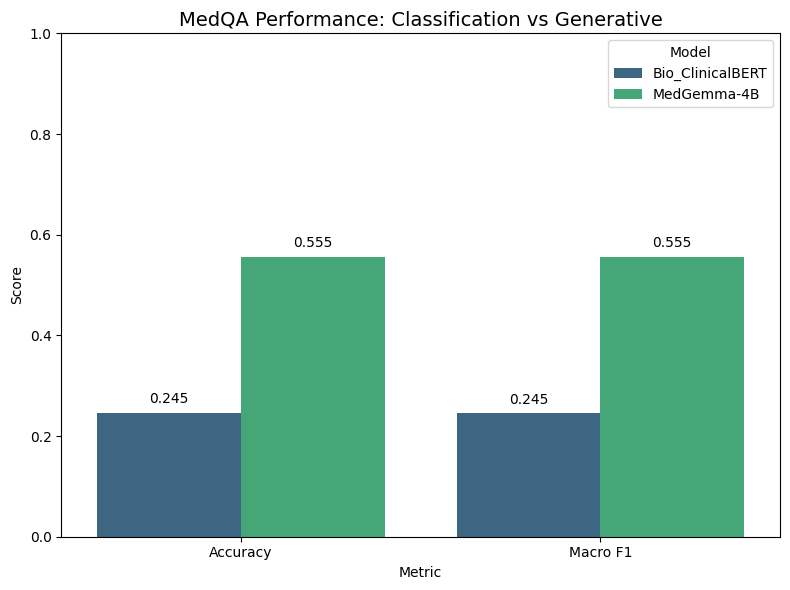

In [ ]:
bert_acc = accuracy_score(true_labels, bert_predictions)
bert_f1 = f1_score(true_labels, bert_predictions, average="macro")

gemma_acc = accuracy_score(true_labels, gemma_predictions)
gemma_f1 = f1_score(true_labels, gemma_predictions, average="macro")

print("="*40)
print(" MEDQA PERFORMANCE COMPARISON")
print("="*40)
print(f"Bio_ClinicalBERT - Accuracy: {bert_acc:.4f} | F1: {bert_f1:.4f}")
print(f"MedGemma-4B      - Accuracy: {gemma_acc:.4f} | F1: {gemma_f1:.4f}")
print("="*40)

results_df = pd.DataFrame({
    "Model": ["Bio_ClinicalBERT", "Bio_ClinicalBERT", "MedGemma-4B", "MedGemma-4B"],
    "Metric": ["Accuracy", "Macro F1", "Accuracy", "Macro F1"],
    "Score": [bert_acc, bert_f1, gemma_acc, gemma_f1]
})

plt.figure(figsize=(8, 6))
sns.barplot(data=results_df, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("MedQA Performance: Classification vs Generative", fontsize=14)
plt.ylim(0, 1.0)

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.3f}", 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                           textcoords='offset points')

plt.tight_layout()
plt.show()

## Conclusions

### 1. Named Entity Recognition (MedMentions)
**BERT** demonstrates significantly higher NER performance than **MedGemma-4B**.

**BERT**'s bidirectional attention allows every token to attend to the full context on both sides simultaneously. Combined with a token classification head trained end-to-end on explicit B-/I-/O labels, the model directly optimizes for exact span boundaries, which is exactly what NER evaluation measures.

**MedGemma** is a decoder-only (GPT-style) model. Its causal left-to-right self attention means each token is blind to tokens that follow it, which is a disadvantage for recognizing entity boundaries (BIO tagging) that depend on right side context. On top of that, the model must generate a free-form string that is then parsed back into labels and any deviation in formatting causes alignment errors which result in lower precision and recall.

It is important to note that BERT was evaluated on the full MedMentions test split, while Gemma was evaluated on a 10% random subset. This means the comparison is not perfect; Gemma's reported metrics carry higher variance and may not fully represent its performance on the complete distribution. The decision to subsample the test set for MedGemma was done due to the material constraints, as inference for this model takes significantly more time, than it does for BERT.

#### Potential improvements for BERT
We can further improve BERT model's results by:
1. Synthesizing and supplementing data for under-represented NER tags.
2. Using whole-word tokenization or SpanBERT.
3. Swapping the base model for a larger one (e.g. `microsoft/BiomedNLP-BiomedBERT-large-uncased`)
4. Adding Conditional Random Field layer to improve sequence labelling in BIO tags.

#### Potential improvements for MedGemma
We can further improve Gemma model's results by:
1. Switching from free-form generation to constrained decoding (e.g. restrict output tokens to valid NER tags only) to eliminate parsing errors.
2. Increasing the training data volume, adding representation to under-represented tags.
3. Using full-precision fine-tuning to recover lost capacity due to quantization.
4. Applying a structured output format (e.g. JSON) during fine-tuning so that the alignment errors are reduced.
5. Using another, larger domain-specific LLM (e.g. `BioMistral-7B`).

### 2. Multiple-Choice QA (MedQA)
**Bio_ClinicalBERT** uses an architecture specifically hardcoded to score 4 inputs against each other. It is fast, but limited by 512-token context window, forcing the truncation of long patient case histories and loss of information, which results in lower performance, and sometimes model's complete inability to answer the question, if the correct option gets truncated.

**MedGemma-4B** shines here. Its large context window (1024+ tokens) allows it to read entire patient histories without truncation. 
The generative constraint on the output does not pose an issue, and the underlying base model is capable of grasping the context and reasoning to give an appropriate answer to the multiple choice question. All of this results in a gigher accuracy and F1 score compared to BERT.

#### Potential improvements for BERT
We can further improve BERT model's results by:
1. Changing the fine tuning to feed the model keywords, instead of the whole question, which will result in reduced tokens consumption and alleviate the truncation issues.
2. Replacing the base model with a longer context one to eliminate the 512 tokens limitation entirely.

#### Potential improvements for MedGemma
We can further improve Gemma model's results by:
1. Prolonging fine tuning.
2. Using Retrieval Augmented Generation (RAG) to provide medically relevant context to the LLM.